In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import optuna 
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import missingno as msno
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import cross_val_score, train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
import statsmodels.api as sm
from sklearn.model_selection import learning_curve
import optuna
#from utils.perm_class import ClassificationCV
import seaborn as sns
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
import json

Using 10% of data (stratified & randomized) for EDA

 - rest of data is holdout data

In [2]:
from sqlalchemy import create_engine
import pandas as pd

server = '.\SQLEXPRESS'
database = 'ClubLoanData'

connection_url = (
    "mssql+pyodbc:///?odbc_connect="
    f"DRIVER={{SQL Server}};SERVER={server};DATABASE={database};Trusted_Connection=yes;"
)

engine = create_engine(connection_url)

try:
    query_sample = """
    SELECT * FROM dbo.loan_model_ready
    WHERE split_flag = 'sample'
    """

    # Holdout data where its remaining 90% of both classes
    query_holdout = """
    SELECT * FROM dbo.loan_model_ready
    WHERE split_flag = 'holdout'
    """

    df_sample = pd.read_sql(query_sample, engine)
    df_holdout = pd.read_sql(query_holdout, engine)

    df_sample.to_csv('../Data/loan_data_sample.csv', index=False)
    df_holdout.to_csv('../Data/loan_data_holdout.csv', index=False)

    print(f"Sample Shape:  {df_sample.shape}")
    print(f"Holdout Shape: {df_holdout.shape}")

    print("\nSample class distribution:")
    print(df_sample['predictor'].value_counts(normalize=True))
    print("\nHoldout class distribution:")
    print(df_holdout['predictor'].value_counts(normalize=True))

except Exception as e:
    print(f"Error: {e}")


c:\Users\Marwa\anaconda3\envs\data_cleaning\Lib\site-packages\pandas\io\sql.py:1648: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


Sample Shape:  (130638, 82)
Holdout Shape: (1175749, 82)

Sample class distribution:
predictor
0    0.799109
1    0.200891
Name: proportion, dtype: float64

Holdout class distribution:
predictor
0    0.799104
1    0.200896
Name: proportion, dtype: float64


In [ ]:

df = pd.read_csv('..\Data\loan_data_sample.csv')
features = ['loan_amnt', 'term', 'emp_length', 'home_ownership',
       'annual_inc', 'verification_status', 'purpose', 'dti', 'delinq_2yrs',
       'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record',
       'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'initial_list_status', 'mths_since_last_major_derog',
       'application_type', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m',
       'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il',
       'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc',
       'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m',
       'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util',
       'chargeoff_within_12_mths', 'mo_sin_old_il_acct',
       'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl',
       'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq',
       'mths_since_recent_inq', 'mths_since_recent_revol_delinq',
       'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl',
       'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl',
       'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m',
       'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m',
       'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies',
       'tax_liens', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit',
       'total_il_high_credit_limit',
       'months_sincefrst_credit', 'public_record', 'is_consolidation',
       'addr_state', 'is_currently_delinq', 'has_il_history']



index_sql = 'Loan_ID'
target = 'predictor'

df_features  = df[features]
df_predictor = pd.Series(df[target])

#print(df_features.shape,df_predictor.shape)

X_train, X_test, y_train,y_test = train_test_split(df_features,df_predictor,stratify=df_predictor,test_size=.2,random_state=11)

categorical_features = X_train.select_dtypes(include=['object','category']).columns.tolist()
numerical_features = X_train.select_dtypes(include=['number']).columns.tolist()

Changing the imputed '999' back to NaN for T-Test. This is to make it more straightforward for other Col's with NaN.

In [4]:
imputed_cols = [
    'mths_since_last_delinq', 'mths_since_last_record', 
    'mths_since_last_major_derog', 'mths_since_recent_bc_dlq', 
    'mths_since_recent_inq', 'mths_since_recent_revol_delinq'
]

for col in imputed_cols:
    X_train[col] = X_train[col].replace(999.0, np.nan)

Target Encoding/Probability Encoding. More effective for highly cardinal data like addr_state. Rest of categorical columns will be OHE. 

- IA had a mean of 0 (no default in training set for IA), we'll use Bayesian smoothing for the whole dataset.

In [5]:
categorical_features = ['home_ownership', 'verification_status', 'application_type', 'addr_state']

X_temp_data = X_train.copy()
X_temp_data['predictor'] = y_train
state_means = X_temp_data.groupby('addr_state')['predictor'].mean()
global_default_mean = y_train.mean()

m= 10 #smoothing parameter
state_means = X_temp_data.groupby('addr_state')['predictor'].mean()
state_counts = X_temp_data['addr_state'].value_counts()
means_smoothed = ((state_counts*state_means)+(m*global_default_mean))/(state_counts+m)

X_train['state_enc'] = X_train['addr_state'].map(means_smoothed)
X_test['state_enc'] = X_test['addr_state'].map(means_smoothed)
X_test['state_enc'] = X_test['state_enc'].fillna(global_default_mean)
categorical_features.remove('addr_state')

X_encoded=pd.get_dummies(X_train[categorical_features],drop_first=True,sparse=False,dtype=int)
X_train = pd.concat([X_train[numerical_features],X_encoded],axis=1)

X_encoded_test = pd.get_dummies(X_test[categorical_features],drop_first=True,sparse=False,dtype=int)
X_test = pd.concat([X_test[numerical_features],X_encoded_test],axis=1)
#align columns
X_test = X_test.reindex(columns=X_train.columns,fill_value=0)

Pipeline for Flags / missing values

In [6]:
from sklearn import set_config


zero_cols = [
    'max_bal_bc', 'all_util', 'il_util', 'open_acc_6m', 
    'open_il_12m', 'open_il_24m', 'open_rv_12m', 'open_rv_24m', 'inq_last_12m',
    'open_act_il', 'total_bal_il', 'total_il_high_credit_limit', 'is_consolidation'
]

flag_cols = [
    'mths_since_last_delinq', 'mths_since_last_record', 
    'mths_since_recent_bc_dlq', 'mths_since_recent_revol_delinq', 
    'mths_since_recent_inq', 'mths_since_rcnt_il',
    'mths_since_last_major_derog'
]

median_cols = [
    'months_sincefrst_credit', 'annual_inc', 'inq_last_6mths', 
    'revol_util', 'total_acc', 'pub_rec', 'open_acc', 
    'mo_sin_old_rev_tl_op', 'num_rev_accts', 'tot_hi_cred_lim',
    'acc_open_past_24mths', 'num_bc_sats', 'num_sats', 'mort_acc',
    'mths_since_recent_bc', 'total_bc_limit', 'pub_rec_bankruptcies',
    'total_rev_hi_lim', 'inq_fi', 'avg_cur_bal', 'bc_open_to_buy', 
    'bc_util', 'mo_sin_old_il_acct', 'mo_sin_rcnt_rev_tl_op', 
    'mo_sin_rcnt_tl', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 
    'num_actv_rev_tl', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 
    'num_rev_tl_bal_gt_0', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 
    'pct_tl_nvr_dlq', 'percent_bc_gt_75',
    'total_cu_tl', 'total_bal_ex_mort', 'num_tl_30dpd', 'num_tl_120dpd_2m', 'chargeoff_within_12_mths'
]

set_config(transform_output="pandas")

preprocessing = ColumnTransformer([
    ('zeros',SimpleImputer(strategy='constant',fill_value=0),zero_cols),
    ('flags',SimpleImputer(strategy= 'median',add_indicator=True),flag_cols),
    ('median',SimpleImputer(strategy='median'),median_cols)
],remainder='passthrough')

X_train = preprocessing.fit_transform(X_train)
X_test = preprocessing.transform(X_test)


In [7]:

# All features now numerical after pipeline/ target encoding
#categorical_features = X_train.select_dtypes(include=['object','category']).columns.tolist()


numerical_features = X_train.select_dtypes(include=['number']).columns.tolist()

Univariate Analysis of features

In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)

result=[]
for column in numerical_features:
    group1 = X_train[y_train == 0 ][column].dropna()
    group2 = X_train[y_train == 1 ][column].dropna()

    t_stat,p_val = stats.ttest_ind(group1,group2,equal_var=False)

    result.append({'Column':column,'p_val':p_val,
                   'Decision': 'Drop' if p_val > 0.05 else 'Keep'})
    

results = pd.DataFrame(result).sort_values(by='p_val')
print(results)

In [8]:
#print(results[results['Decision']=='Drop']['Column'])

cols_to_drop=['flags__mths_since_last_delinq','median__num_rev_accts','zeros__total_il_high_credit_limit',
              'zeros__is_consolidation','median__num_tl_30dpd','flags__mths_since_last_major_derog',
              'remainder__home_ownership_OWN','flags__mths_since_rcnt_il','remainder__is_currently_delinq',
              'flags__mths_since_recent_bc_dlq','median__total_bal_ex_mort',
              'remainder__home_ownership_OTHER','remainder__home_ownership_NONE','median__num_tl_120dpd_2m','flags__mths_since_last_record']


X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

Feature Engineering

In [9]:
eps = 0.001 # to avoid dividing by zero
# 1. Loan-to-Income
#X_train['FE_loan_to_income'] = X_train['remainder__loan_amnt'] / (X_train['median__annual_inc'] + eps)
#X_test['FE_loan_to_income'] = X_test['remainder__loan_amnt'] / (X_test['median__annual_inc'] + eps)

# 2. Monthly Free Cash Flow
X_train['FE_free_cash_flow'] = (X_train['median__annual_inc'] / 12) * (1 - (X_train['remainder__dti'] / 100))
X_test['FE_free_cash_flow'] = (X_test['median__annual_inc'] / 12) * (1 - (X_test['remainder__dti'] / 100))

# 3. Credit Line Activity Ratio
X_train['FE_activity_ratio'] = X_train['median__num_actv_rev_tl'] / (X_train['median__num_op_rev_tl'] + eps)
X_test['FE_activity_ratio'] = X_test['median__num_actv_rev_tl'] / (X_test['median__num_op_rev_tl'] + eps)

MI/Correlation/ VIF 

In [10]:
cols_to_drops = [
    'remainder__home_ownership_OWN',
    'median__num_sats',
    'flags__missingindicator_mths_since_last_record',
    'median__pct_tl_nvr_dlq',
    'remainder__public_record',
    'median__total_acc',
    'median__num_rev_accts',
    #SECOND ROUND of drops:
    'median__annual_inc',
    'median__num_rev_tl_bal_gt_0',
    'remainder__tot_cur_bal',
    'median__num_op_rev_tl',
    'remainder__home_ownership_NONE',
    'median__chargeoff_within_12_mths',
    #third and final
    'median__months_sincefrst_credit',
    'median__revol_util',
    'median__num_actv_bc_tl',
    'flags__missingindicator_mths_since_rcnt_il',
    'median__total_bc_limit',
    'median__open_acc',
    'flags__missingindicator_mths_since_recent_revol_delinq',
    'median__num_tl_op_past_12m',
    'median__num_bc_tl'
]

X_train = X_train.drop(columns=cols_to_drops, errors='ignore')
X_test = X_test.drop(columns=cols_to_drops, errors='ignore')

In [41]:
pd.set_option('display.max_columns', None)  
pd.set_option('display.width', 200)  
pd.set_option('display.expand_frame_repr', False) 



vif_list = [variance_inflation_factor(X_train.values, i ) 
              for i in range(len(X_train.columns))]

mi = mutual_info_classif(X_train,y_train,random_state=11)

corr = X_train.corrwith(y_train)
corr = corr.abs()


vmc= pd.DataFrame({
    'feature':X_train.columns,
    'VIF':vif_list,
    'Corr with target': corr.values,
    'Mutual Information': mi
})



vmc = vmc.sort_values(by='VIF',ascending=False).reset_index(drop=True)
print(vmc)


                                                feature        VIF  Corr with target  Mutual Information
0                                       median__bc_util  25.310456          0.071276            0.004328
1                             remainder__has_il_history  20.112435          0.016097            0.012967
2                                       remainder__term  19.207303          0.174618            0.021245
3                                     FE_activity_ratio  17.793271          0.060687            0.003632
4                               median__num_actv_rev_tl  12.666503          0.071175            0.003091
5                                    remainder__purpose  12.280229          0.043038            0.013995
6                               median__tot_hi_cred_lim  11.356792          0.074702            0.003964
7                                       zeros__all_util  10.565285          0.069760            0.003715
8                                   median__num_bc_sats

In [42]:
vif_list = list(vmc[vmc['VIF']>10]['feature'])

print(vif_list)

['median__bc_util', 'remainder__has_il_history', 'remainder__term', 'FE_activity_ratio', 'median__num_actv_rev_tl', 'remainder__purpose', 'median__tot_hi_cred_lim', 'zeros__all_util', 'median__num_bc_sats']


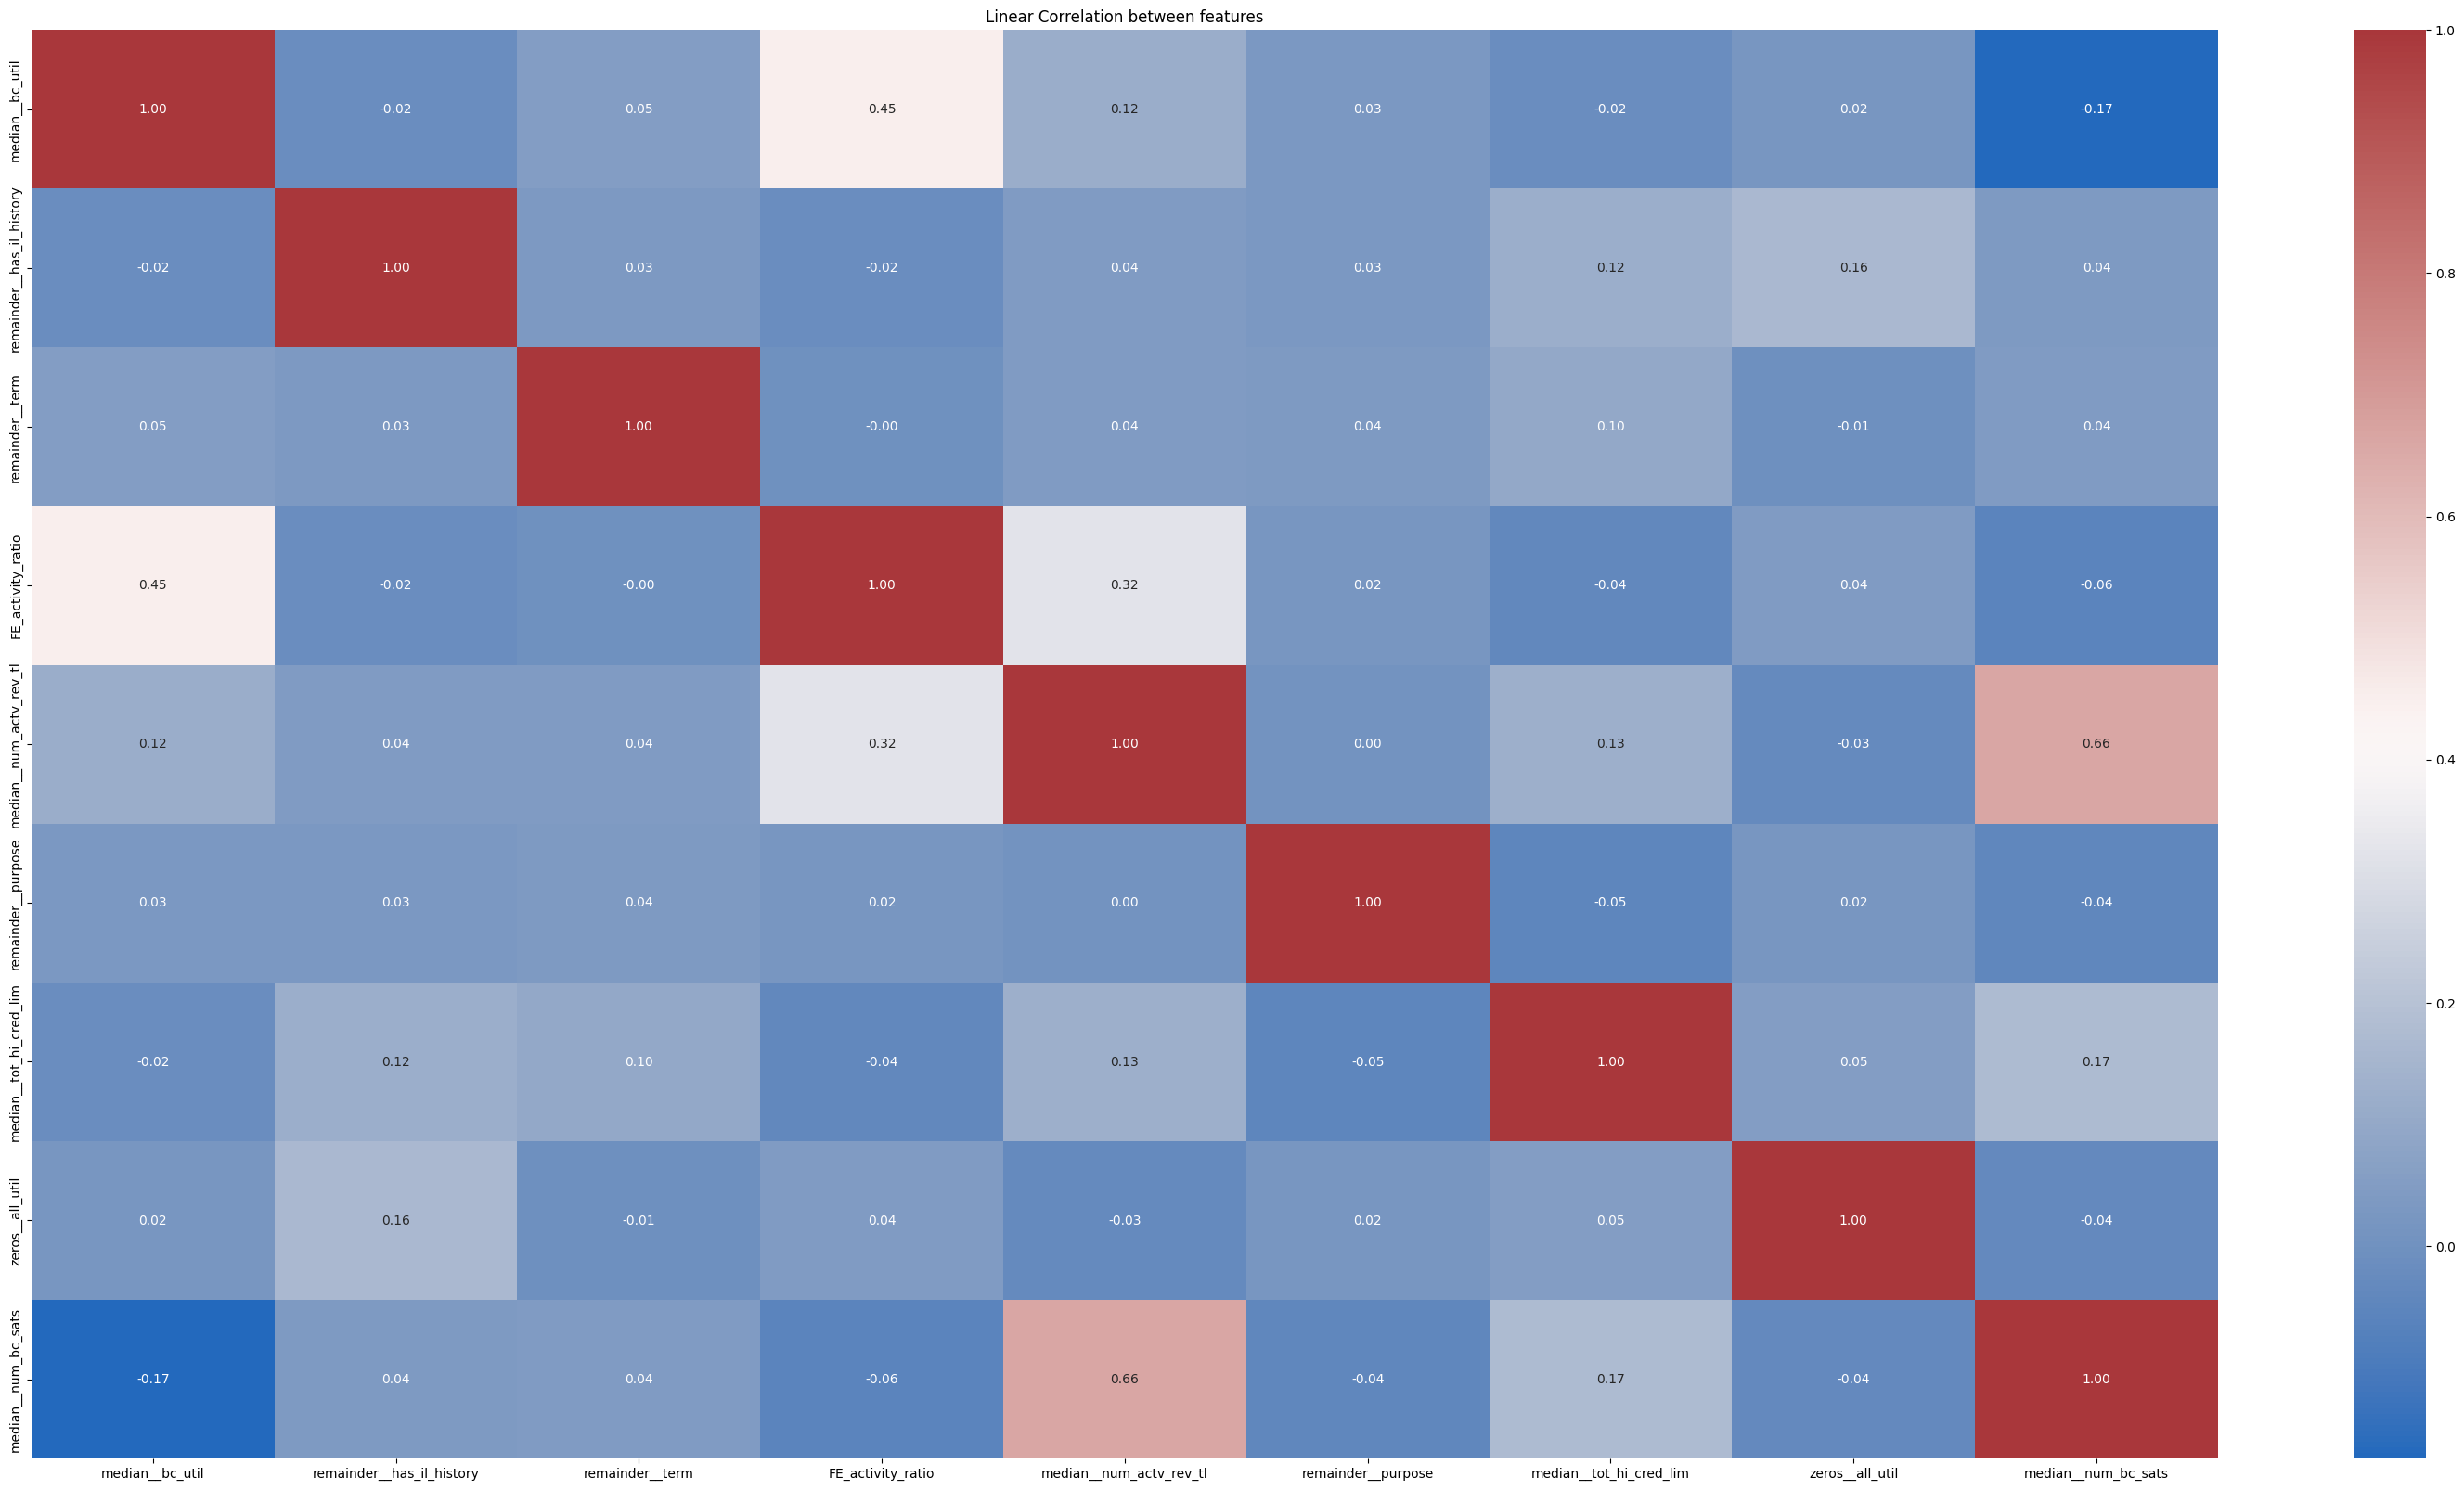

In [ ]:


X_cor = X_train[vif_list]
plt.figure(figsize=(38,20))
sns.heatmap(X_cor.corr(numeric_only=True), annot=True,fmt='.2f',cmap='vlag')
plt.title('Linear Correlation between features')

plt.savefig('Images_log/corr_heatmap2.png',dpi=300,bbox_inches='tight')

plt.show()

Outlier Analysis

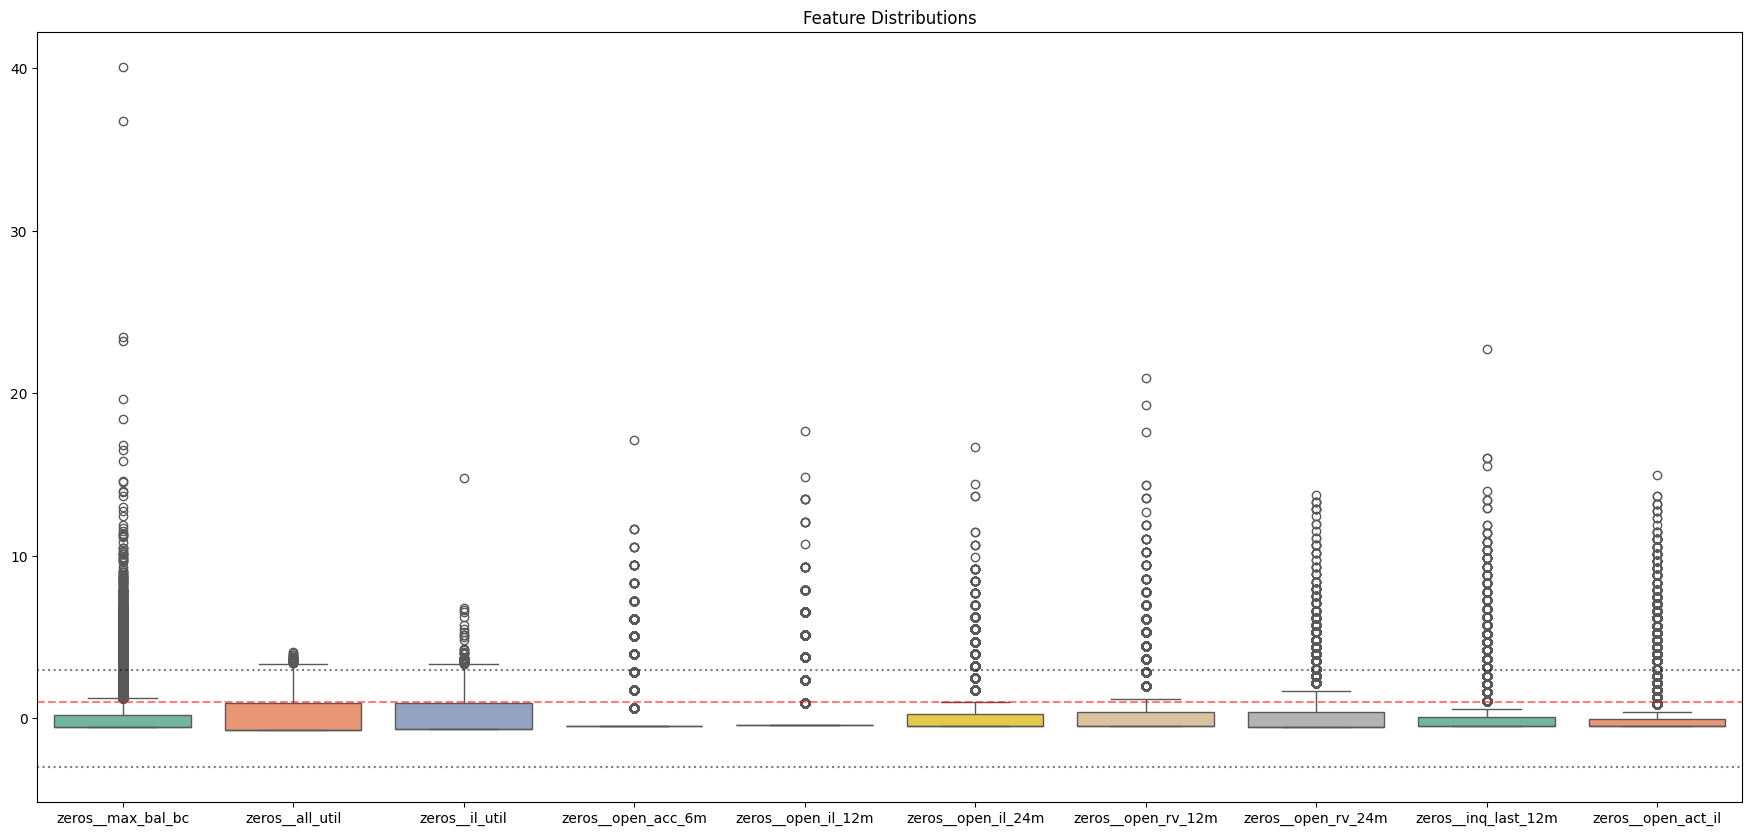

KeyboardInterrupt: 

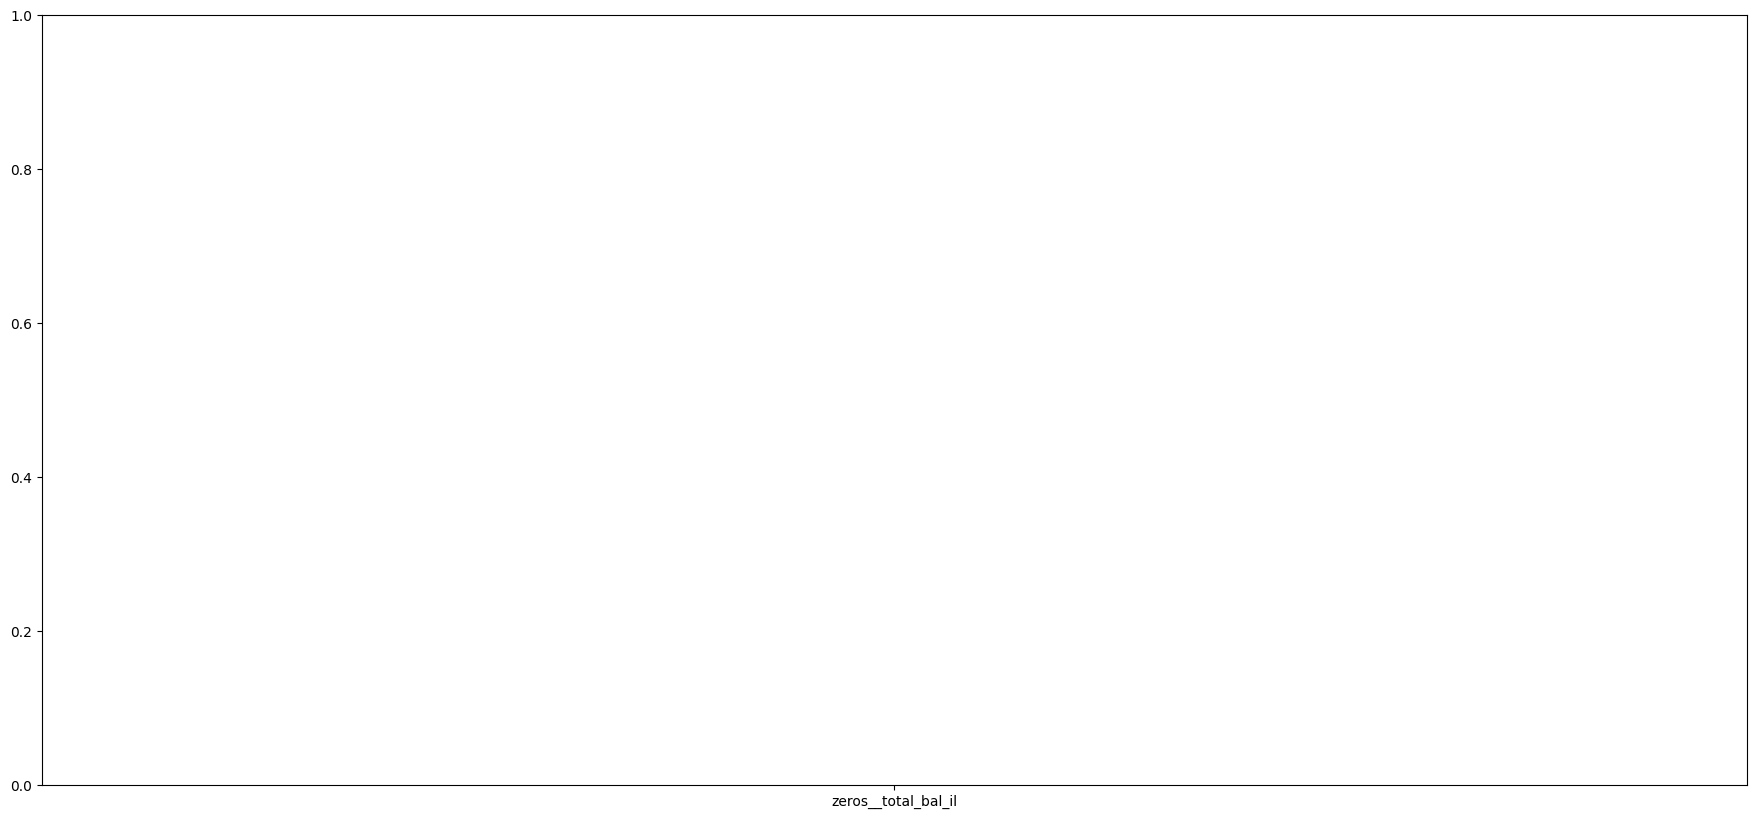

In [25]:
feat_perplot = 10
scale = StandardScaler()
features =X_train.columns
X_train_scaled = scale.fit_transform(X_train)
#X_train_scaled = pd.DataFrame(X_train_scaled,columns=X_train)

for i in range(0,len(features),feat_perplot):
    chunk = features[i:i+feat_perplot]

    plt.figure(figsize=(22,10))
    sns.boxplot(data=X_train_scaled[chunk],palette='Set2')
    plt.title(f'Feature Distributions')
    plt.axhline(y=1,color='red',linestyle='--',alpha=0.5)

    plt.axhline(y=3,color='black',linestyle=':',alpha=0.5)
    plt.axhline(y=-3,color='black',linestyle=':',alpha=0.5)
    plt.show()

Winsorize

In [11]:
upperbounds = X_train.quantile(0.99)
lowerbounds = X_train.quantile(.01)

X_train = X_train.clip(lower=lowerbounds,upper=upperbounds,axis=1)
X_test = X_test.clip(lower=lowerbounds,upper=upperbounds,axis=1)

Cohen's D and Confidence intervals -- manual calculation

In [27]:
pd.set_option('display.max_columns', None)  
pd.set_option('display.width', 200)  
pd.set_option('display.expand_frame_repr', False)

def ci_cohen(X,y):
    df = X.copy()

    df['predictor'] = y

    group_one = df[df['predictor']==1]
    group_zero = df[df['predictor']==0]

    features = X.columns

    results = []
    for i in features:
        g_1 = group_one[i]
        g_0 = group_zero[i]

        n_1 ,n_0 = len(g_1),len(g_0)
        mean_1,mean_0= np.mean(g_1),np.mean(g_0)
        var_1,var_0 = np.var(g_1,ddof=1),np.var(g_0,ddof=1)


        s_pooled = np.sqrt(((n_1-1)* var_1+(n_0-1)*var_0)
                           /(n_1+n_0-2))
        
        d= (mean_1- mean_0)/(s_pooled)

        se_diff = np.sqrt((var_1/n_1)+(var_0/n_0))
        margin_of_error = 1.96*se_diff

        diff_means = mean_1-mean_0
        ci_lower = diff_means - margin_of_error
        ci_upper = diff_means + margin_of_error

        results.append({
            'Feature':i,
            'Cohens d':abs(round(d,2)),
            'CI, (lower,Upper)':f'{round(ci_lower,2)}, {round(ci_upper,2)}',
            'mean difference (default-paid)': round(diff_means,2)
        })
    
    results_df = pd.DataFrame(results).sort_values(by='Cohens d',ascending=False).reset_index(drop=True)

    return(results_df)


cohen_ci = ci_cohen(X_train,y_train)
print(cohen_ci)

                                              Feature  Cohens d   CI, (lower,Upper)  mean difference (default-paid)
0                                     remainder__term      0.44           4.3, 4.64                            4.47
1                                      remainder__dti      0.27          2.13, 2.39                            2.26
2                        median__acc_open_past_24mths      0.25          0.69, 0.79                            0.74
3             remainder__verification_status_Verified      0.22           0.1, 0.11                            0.10
4                              median__bc_open_to_buy      0.22   -3080.43, -2737.1                        -2908.77
5                                 median__avg_cur_bal      0.20   -2950.86, -2576.7                        -2763.78
6                             median__tot_hi_cred_lim      0.19  -32305.8, -28001.1                       -30153.45
7                                  zeros__open_rv_24m      0.19         

Model + cv  for roc auc 

In [15]:
logreg = Pipeline([
    ('scaler',StandardScaler()),
    ('model',LogisticRegression(max_iter=1000,random_state=11,class_weight='balanced'))
])

cvr = cross_val_score(logreg,
                      X_train,
                      y_train,
                      cv=5,
                      scoring='roc_auc',
                      n_jobs=-1)

print(cvr)
print(f'Mean {cvr.mean()}')
print(f'Std. {cvr.std()}')

[0.69950638 0.70659691 0.70082593 0.70390687 0.70252757]
Mean 0.702672730185514
Std. 0.002464947911049103


Hypertune our Logistic Regression using optuna:

In [16]:
def objective_log(trial):

    penalty = trial.suggest_categorical('penalty', ['l1', 'l2', 'elasticnet', None])
    
    if penalty == 'l1':
        solver = trial.suggest_categorical('solver_l1', ['liblinear', 'saga'])
    elif penalty == 'elasticnet':
        solver = 'saga'  
    elif penalty == 'l2':
        solver = trial.suggest_categorical('solver_l2', ['lbfgs', 'newton-cg', 'saga', 'liblinear'])
    else:
        solver = trial.suggest_categorical('solver_none', ['lbfgs', 'newton-cg', 'saga'])

    params = {
        'C': trial.suggest_float('C', 1e-4, 100.0, log=True),
        'penalty': penalty,
        'solver': solver,
        'max_iter': trial.suggest_int('max_iter', 500, 2000), # Increased for convergence
        'tol': trial.suggest_float('tol', 1e-5, 1e-2, log=True),
    }
    
    if penalty == 'elasticnet':
        params['l1_ratio'] = trial.suggest_float('l1_ratio', 0.0, 1.0)
    
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('LinearR', LogisticRegression(**params, random_state=11,class_weight='balanced'))
    ])

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=11),
        scoring='roc_auc',
        n_jobs=-1
    )

    return scores.mean()

study_log = optuna.create_study(direction='maximize')
study_log.optimize(objective_log,n_trials=20)

print(f'Best AUC: {study_log.best_value}')
print(f'Best Params')

for k,v in study_log.best_params.items():
    print(f'{k}:{v}')


[I 2026-03-07 17:15:32,584] A new study created in memory with name: no-name-858c2889-f54a-4130-a3aa-90feb2a41ebf
[I 2026-03-07 17:15:39,862] Trial 0 finished with value: 0.7025189129700451 and parameters: {'penalty': 'l2', 'solver_l2': 'liblinear', 'C': 0.4351511938310731, 'max_iter': 788, 'tol': 0.00014002931540538167}. Best is trial 0 with value: 0.7025189129700451.
[I 2026-03-07 17:15:47,988] Trial 1 finished with value: 0.7025363124901849 and parameters: {'penalty': 'l1', 'solver_l1': 'saga', 'C': 0.2668209386555995, 'max_iter': 1933, 'tol': 7.779620493655344e-05}. Best is trial 1 with value: 0.7025363124901849.
[I 2026-03-07 17:15:53,912] Trial 2 finished with value: 0.7025615398984089 and parameters: {'penalty': 'l1', 'solver_l1': 'saga', 'C': 0.11564909428045714, 'max_iter': 1282, 'tol': 0.006319591869609399}. Best is trial 2 with value: 0.7025615398984089.
[I 2026-03-07 17:16:03,381] Trial 3 finished with value: 0.7026113136751124 and parameters: {'penalty': 'elasticnet', 'C':

Best AUC: 0.7026152319274571
Best Params
penalty:elasticnet
C:0.009633535218310006
max_iter:1459
tol:0.000644145703653442
l1_ratio:0.5652720624840502


Learning Curve

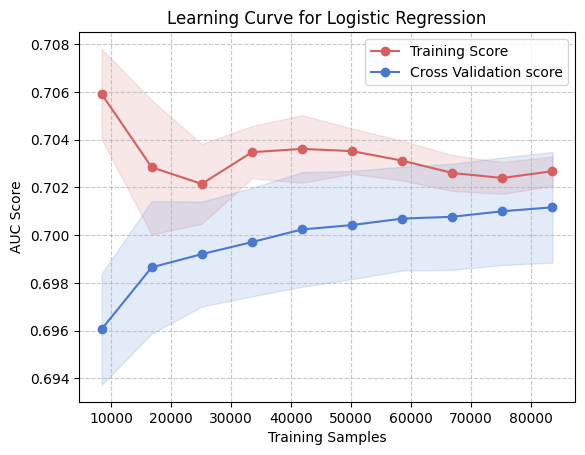

In [ ]:
def plot_learning_curve(estimator,X,y):
    train_sizes,train_scores,test_scores = learning_curve(
        estimator,X,y,cv=5,n_jobs=-1,
        train_sizes=np.linspace(0.1,1,10),
        scoring='roc_auc'
    )
    train_mean = np.mean(train_scores,axis=1)
    train_std = np.std(train_scores,axis=1)
    test_mean = np.mean(test_scores,axis=1)
    test_std = np.std(test_scores,axis=1)

    plt.plot(train_sizes,train_mean,label='Training Score',color='#d65f5f',marker='o')
    plt.fill_between(train_sizes,train_mean - train_std,train_mean+train_std,alpha=0.15,color='#d65f5f')

    plt.plot(train_sizes,test_mean,label='Cross Validation score',color='#4878d0', marker='o')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='#4878d0')

    plt.title("Learning Curve for Logistic Regression")
    plt.xlabel('Training Samples')
    plt.ylabel('AUC Score')
    plt.legend()
    plt.grid(True,linestyle='--', alpha=0.7)
    plt.savefig('Images_log/LearningCurve_Log.png',dpi=300,bbox_inches='tight')
    plt.show()


refined_params_model= Pipeline([
    ('scaler', StandardScaler()),
    ('LinearR', LogisticRegression(C=0.18524697655221053,max_iter=1991,tol=0.005427682703976469,
                                   solver='saga',penalty='l1',random_state=11,class_weight='balanced'))
    ])

plot_learning_curve(refined_params_model,X_train,y_train)
#std/mean --> cv=5

weights -> plots

In [54]:
refined_params_model= Pipeline([
    ('scaler', StandardScaler()),
    ('LinearR', LogisticRegression(C=0.18524697655221053,max_iter=1991,tol=0.005427682703976469,
                                   solver='saga',penalty='l1',random_state=11,class_weight='balanced'))
    ])

refined_params_model.fit(X_train,y_train)
model  = refined_params_model.named_steps['LinearR']
coefs = model.coef_[0]
odds_ratios = np.exp(coefs)


features=X_train.columns

model_results = pd.DataFrame({
    'Feature':features,
    'Coef':coefs,
    'odds':odds_ratios
})
mr = model_results.sort_values(by='odds').reset_index(drop=True)
print(mr)

c:\Users\Marwa\anaconda3\envs\data_cleaning\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Marwa\anaconda3\envs\data_cleaning\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


                                              Feature      Coef      odds
0                              median__bc_open_to_buy -0.135746  0.873064
1                                   FE_free_cash_flow -0.133944  0.874639
2                             median__tot_hi_cred_lim -0.130045  0.878055
3                                    median__mort_acc -0.102772  0.902333
4                                   median__num_il_tl -0.090065  0.913872
5                               remainder__emp_length -0.072065  0.930470
6                  remainder__home_ownership_MORTGAGE -0.071280  0.931201
7                        median__mths_since_recent_bc -0.069682  0.932691
8       flags__missingindicator_mths_since_recent_inq -0.065201  0.936880
9                        flags__mths_since_recent_inq -0.059088  0.942624
10                       median__mo_sin_old_rev_tl_op -0.059073  0.942638
11                           median__total_rev_hi_lim -0.057978  0.943671
12  flags__missingindicator_mths_since

Weight Plot

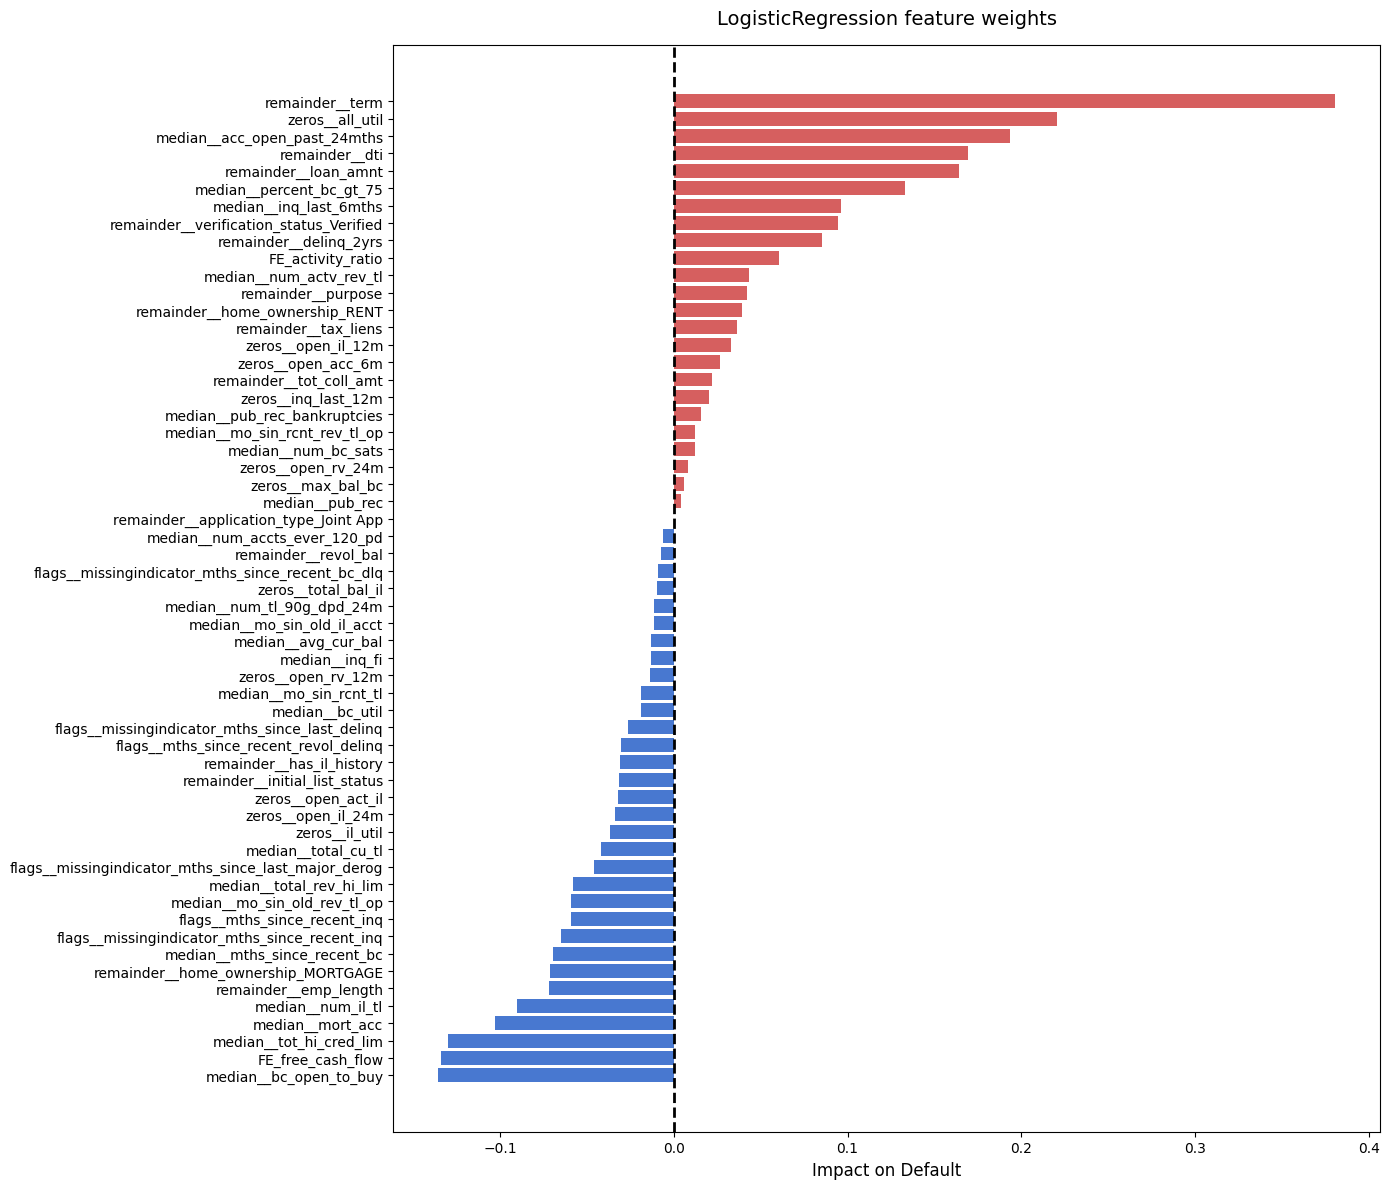

In [ ]:
plt.figure(figsize=(14,12))
colors = ['#d65f5f' if c>0 else '#4878d0' for c in mr['Coef']]

plt.barh(mr['Feature'], mr['Coef'],color=colors)
plt.axvline(x=0,color='black',linestyle='--',linewidth=2)
plt.title('LogisticRegression feature weights',fontsize=14,pad=15)
plt.xlabel('Impact on Default',fontsize=12)
plt.savefig('Images_log/LogisticRegression_feature_weight.png',dpi=300,bbox_inches='tight')

plt.tight_layout()
plt.show()



In [57]:
mr_abs = mr.loc[:,['Feature','Coef','odds']]
mr_abs['abs Coef'] = mr_abs['Coef'].abs()
mr_abs=mr_abs.sort_values(by='abs Coef',ascending=False)
mr_abs=mr_abs.drop('Coef',axis=1)
print(mr_abs.head(10))

                         Feature      odds  abs Coef
56               remainder__term  1.463258  0.380665
55               zeros__all_util  1.246738  0.220530
54  median__acc_open_past_24mths  1.213524  0.193528
53                remainder__dti  1.184395  0.169232
52          remainder__loan_amnt  1.178566  0.164299
0         median__bc_open_to_buy  0.873064  0.135746
1              FE_free_cash_flow  0.874639  0.133944
51      median__percent_bc_gt_75  1.142372  0.133107
2        median__tot_hi_cred_lim  0.878055  0.130045
3               median__mort_acc  0.902333  0.102772


Multivariate analysis and confirming significance

In [62]:
scaler  = refined_params_model.named_steps['scaler']
X_train_scaled = scaler.transform(X_train)
X_train_scaled_df = pd.DataFrame(
    X_train_scaled, 
    columns=X_train.columns, 
    index=X_train.index
)

model = sm.Logit(y_train, X_train_scaled_df.assign(const=1))
results = model.fit()
print(results.summary())

Optimization terminated successfully.
         Current function value: 0.458861
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              predictor   No. Observations:               104511
Model:                          Logit   Df Residuals:                   104453
Method:                           MLE   Df Model:                           57
Date:                Fri, 06 Mar 2026   Pseudo R-squ.:                 0.08529
Time:                        00:19:58   Log-Likelihood:                -47956.
converged:                       True   LL-Null:                       -52427.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                          coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------
zeros__max_bal_bc         

In [12]:
#dropping insig col's
kill_list = [
    'zeros__max_bal_bc',          
    'zeros__open_rv_12m',     
    'zeros__open_rv_24m',       
    'zeros__inq_last_12m',      
    'zeros__total_bal_il',        
    'flags__missingindicator_mths_since_recent_bc_dlq', 
    'median__pub_rec',             
    'median__num_bc_sats',         
    'median__pub_rec_bankruptcies', 
    'median__total_rev_hi_lim',    
    'median__inq_fi',              
    'median__avg_cur_bal',         
    'median__bc_util',             
    'median__mo_sin_old_il_acct',  
    'median__mo_sin_rcnt_rev_tl_op', 
    'median__num_accts_ever_120_pd', 
    'median__num_tl_90g_dpd_24m',  
    'remainder__revol_bal',        
    'remainder__application_type_Joint App' 
]

# Drop them from your training and testing sets
X_train = X_train.drop(columns=kill_list)
X_test = X_test.drop(columns=kill_list)

rerun model with optuna two birds one stone

In [65]:
def objective_log(trial):

    penalty = trial.suggest_categorical('penalty', ['l1', 'l2', 'elasticnet', None])
    
    if penalty == 'l1':
        solver = trial.suggest_categorical('solver_l1', ['liblinear', 'saga'])
    elif penalty == 'elasticnet':
        solver = 'saga'  
    elif penalty == 'l2':
        solver = trial.suggest_categorical('solver_l2', ['lbfgs', 'newton-cg', 'saga', 'liblinear'])
    else:
        solver = trial.suggest_categorical('solver_none', ['lbfgs', 'newton-cg', 'saga'])

    params = {
        'C': trial.suggest_float('C', 1e-4, 100.0, log=True),
        'penalty': penalty,
        'solver': solver,
        'max_iter': trial.suggest_int('max_iter', 500, 2000), # Increased for convergence
        'tol': trial.suggest_float('tol', 1e-5, 1e-2, log=True),
    }
    
    if penalty == 'elasticnet':
        params['l1_ratio'] = trial.suggest_float('l1_ratio', 0.0, 1.0)
    
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('LinearR', LogisticRegression(**params, random_state=11,class_weight='balanced'))
    ])

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=11),
        scoring='roc_auc',
        n_jobs=-1
    )

    return scores.mean()

study_log = optuna.create_study(direction='maximize')
study_log.optimize(objective_log,n_trials=20)

print(f'Best AUC: {study_log.best_value}')
print(f'Best Params')

for k,v in study_log.best_params.items():
    print(f'{k}:{v}')

[I 2026-03-06 00:42:06,435] A new study created in memory with name: no-name-a76b1141-7194-432a-bde2-b41bf22d831b
[I 2026-03-06 00:42:08,339] Trial 0 finished with value: 0.7013550164217687 and parameters: {'penalty': None, 'solver_none': 'lbfgs', 'C': 98.9862236343257, 'max_iter': 813, 'tol': 0.0006082320674324433}. Best is trial 0 with value: 0.7013550164217687.
[I 2026-03-06 00:42:13,781] Trial 1 finished with value: 0.7013610857273409 and parameters: {'penalty': 'elasticnet', 'C': 42.310570487399886, 'max_iter': 1425, 'tol': 0.0010165337768405255, 'l1_ratio': 0.14404209072126206}. Best is trial 1 with value: 0.7013610857273409.
[I 2026-03-06 00:42:16,819] Trial 2 finished with value: 0.6972106355072082 and parameters: {'penalty': 'elasticnet', 'C': 0.00031384590539174697, 'max_iter': 1837, 'tol': 0.003546581380437174, 'l1_ratio': 0.23206651096310427}. Best is trial 1 with value: 0.7013610857273409.
[I 2026-03-06 00:42:18,618] Trial 3 finished with value: 0.7013591360444004 and para

Best AUC: 0.701368311548215
Best Params
penalty:elasticnet
C:90.31097151134563
max_iter:1595
tol:0.009993372798221852
l1_ratio:0.6871072356705394


Effect plot

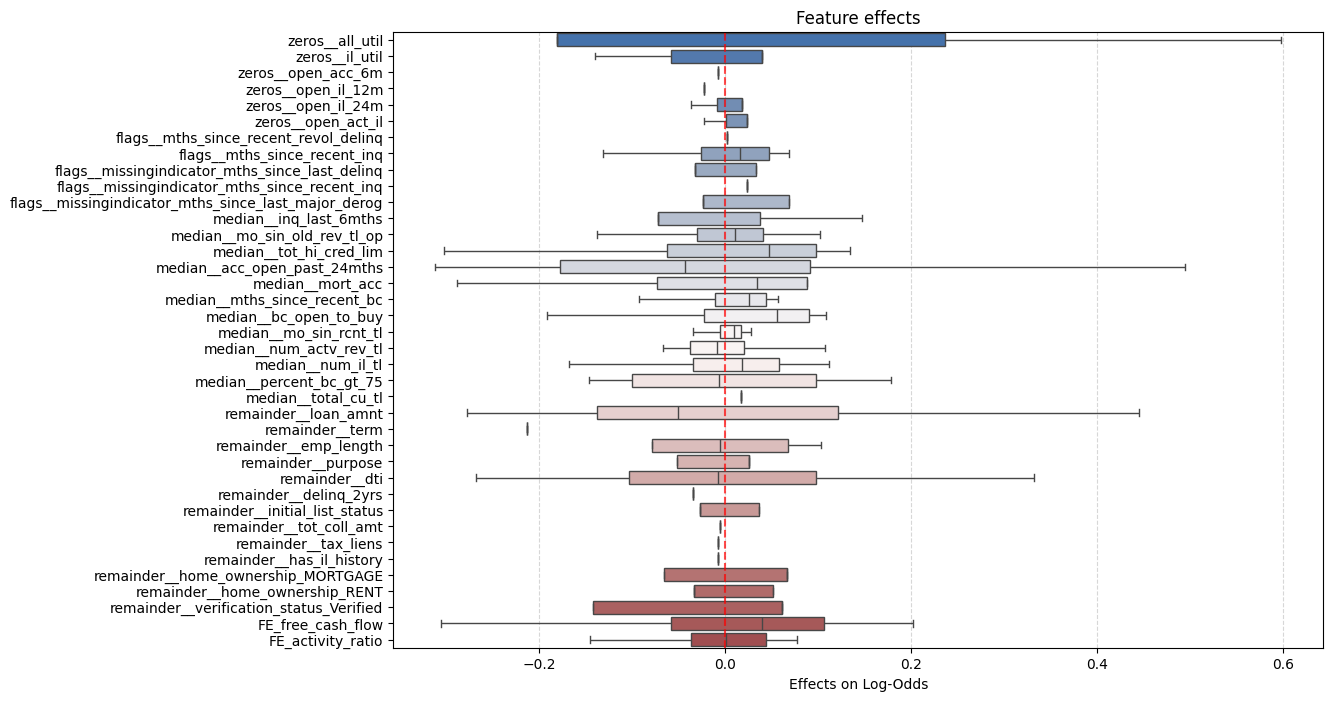

In [ ]:
params = {
    'C':90.31097151134563,
    'solver':'saga',
    'max_iter':1595,
    'tol':0.009993372798221852,
    'l1_ratio':0.6871072356705394
}

model = Pipeline([
        ('scaler', StandardScaler()),
        ('LinearR', LogisticRegression(**params, random_state=11,class_weight='balanced'))
    ])

model.fit(X_train,y_train)

#repeating because different columns before.
scaler = model.named_steps['scaler']
X_train_scaled = scaler.transform(X_train)
X_train_scaled_df = pd.DataFrame(X_train_scaled,columns=X_train.columns)
weights = model.named_steps['LinearR'].coef_[0]


effects_df = X_train_scaled_df * weights

means_abs_effects = effects_df.abs().mean().sort_values(ascending=False)

plt.figure(figsize=(12,8))
sns.boxplot(
    data=effects_df,
    orient='h',
    palette='vlag',
    showfliers=False, #take out outliers
)

plt.axvline(x=0,color='red',linestyle='--',linewidth=1.5,alpha=0.7)
plt.title('Feature effects')
plt.xlabel('Effects on Log-Odds')
plt.grid(axis='x',linestyle='--',alpha=0.5)

#plt.savefig('Images_log/Logreg_effectplot.png',dpi=300,bbox_inches='tight')
plt.show()

In [18]:
params = {
    'C':90.31097151134563,
    'solver':'saga',
    'max_iter':1595,
    'tol':0.009993372798221852,
    'l1_ratio':0.6871072356705394
}

model = Pipeline([
        ('scaler', StandardScaler()),
        ('LinearR', LogisticRegression(**params, random_state=11,class_weight='balanced'))
    ])

model.fit(X_train,y_train)
y_test_proba=model.predict_proba(X_test)[:,1]
test_auc = roc_auc_score(y_test,y_test_proba)

print(f"Test AUC: {test_auc:.3f}")
print(f"Train AUC (CV): 0.7026")
print(f"Difference: {abs(test_auc - 0.7026):.3f}")

Test AUC: 0.697
Train AUC (CV): 0.7026
Difference: 0.005
